# E Minor Scale — Audio Exploration
Pre-executed: scroll to see plots and listen to the scale.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import IPython.display as ipd

SR = 22050

NOTE_NAMES = ['E4', 'F#4', 'G4', 'A4', 'B4', 'C5', 'D5', 'E5']
FREQS = [329.63, 369.99, 392.00, 440.00, 493.88, 523.25, 587.33, 659.25]

NOTE_DUR = 0.5
FADE = 0.02

signal = np.array([], dtype=np.float64)
for freq in FREQS:
    t = np.linspace(0, NOTE_DUR, int(SR * NOTE_DUR), endpoint=False)
    note = 0.5 * np.sin(2 * np.pi * freq * t)
    fade_len = int(FADE * SR)
    note[:fade_len] *= np.linspace(0, 1, fade_len)
    note[-fade_len:] *= np.linspace(1, 0, fade_len)
    signal = np.concatenate([signal, note])

DURATION = len(signal) / SR
print(f'E minor scale: {" -> ".join(NOTE_NAMES)}')
print(f'{DURATION:.1f}s total  |  {NOTE_DUR}s per note  |  shape={signal.shape}')

E minor scale: E4 -> F#4 -> G4 -> A4 -> B4 -> C5 -> D5 -> E5
4.0s total  |  0.5s per note  |  shape=(88200,)


## Listen

In [2]:
ipd.Audio(signal, rate=SR)

## Waveform

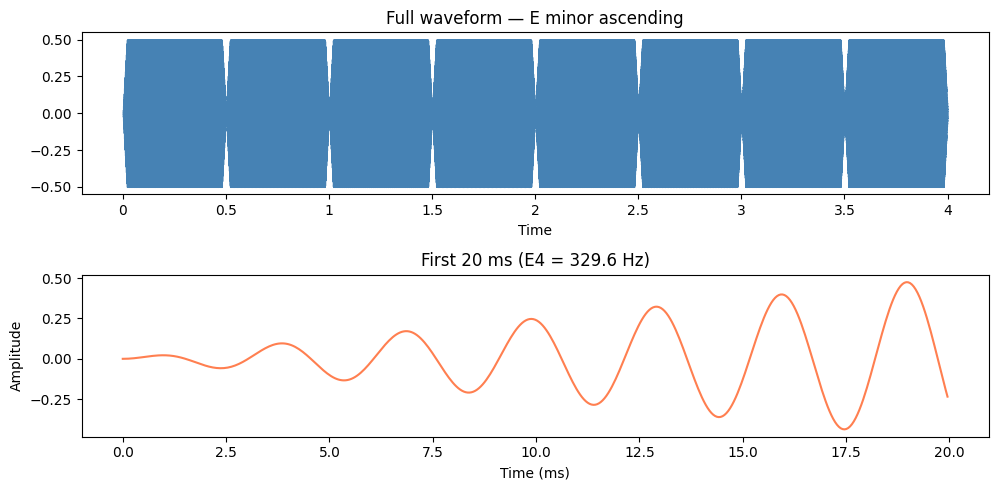

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5))
librosa.display.waveshow(signal, sr=SR, ax=axes[0], color='steelblue')
axes[0].set_title('Full waveform — E minor ascending')
n = int(0.02 * SR)
t_zoom = np.linspace(0, 0.02, n, endpoint=False) * 1000
axes[1].plot(t_zoom, signal[:n], color='coral')
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Amplitude')
axes[1].set_title('First 20 ms (E4 = 329.6 Hz)')
plt.tight_layout()
plt.show()

## Spectrogram
You should see a staircase of bright lines stepping up through the scale.

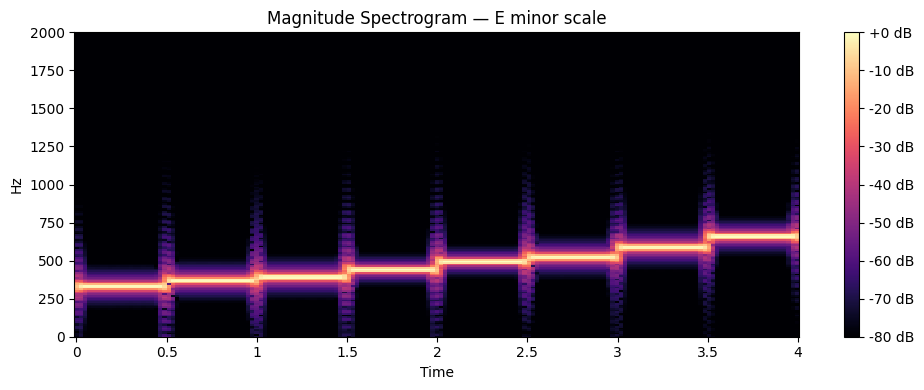

In [ ]:
S = librosa.stft(signal, n_fft=2048, hop_length=512)
S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)
fig, ax = plt.subplots(figsize=(10, 4))
img = librosa.display.specshow(S_db, sr=SR, hop_length=512,
                               x_axis='time', y_axis='hz', ax=ax, cmap='magma')
fig.colorbar(img, ax=ax, format='%+2.0f dB')
ax.set_title('Magnitude Spectrogram — E minor scale')
ax.set_ylim(0, 2000)
plt.tight_layout()
plt.show()

## Mel Spectrogram

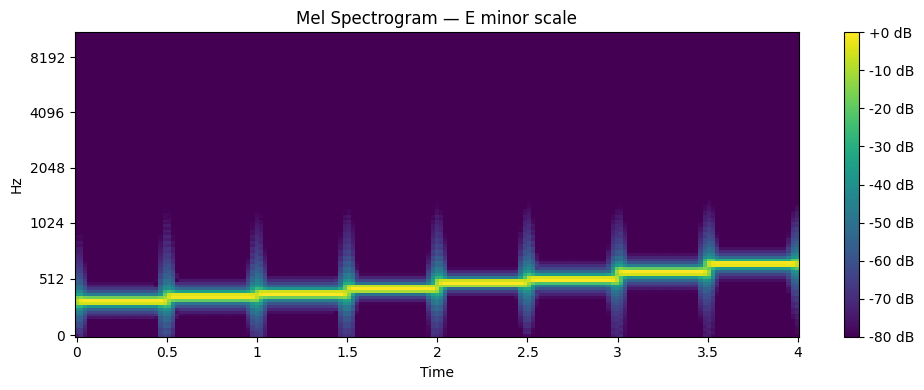

In [ ]:
S_mel = librosa.feature.melspectrogram(y=signal, sr=SR, n_fft=2048,
                                       hop_length=512, n_mels=128)
S_mel_db = librosa.power_to_db(S_mel, ref=np.max)
fig, ax = plt.subplots(figsize=(10, 4))
img = librosa.display.specshow(S_mel_db, sr=SR, hop_length=512,
                               x_axis='time', y_axis='mel', ax=ax, cmap='viridis')
fig.colorbar(img, ax=ax, format='%+2.0f dB')
ax.set_title('Mel Spectrogram — E minor scale')
plt.tight_layout()
plt.show()

## MFCCs

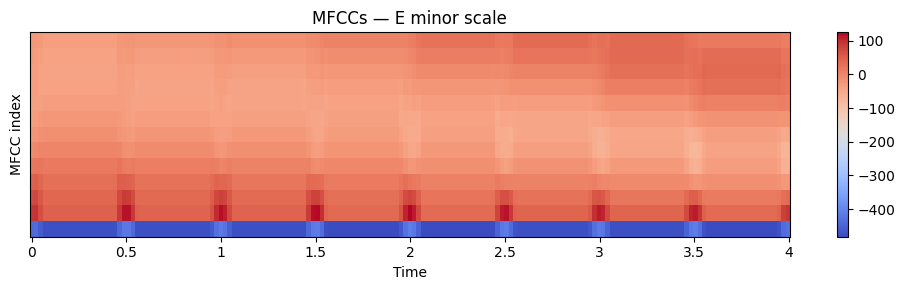

In [ ]:
mfccs = librosa.feature.mfcc(y=signal, sr=SR, n_mfcc=13,
                              n_fft=2048, hop_length=512)
fig, ax = plt.subplots(figsize=(10, 3))
img = librosa.display.specshow(mfccs, sr=SR, hop_length=512,
                               x_axis='time', ax=ax)
fig.colorbar(img, ax=ax)
ax.set_title('MFCCs — E minor scale')
ax.set_ylabel('MFCC index')
plt.tight_layout()
plt.show()